# Supervised Learning with Housing Data

A practical introduction to regression and classification using the local Day 3 dataset.


## my goal

Train supervised-learning models, evaluate unseen predictions and identify the most useful features.


## 1. imports


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (ConfusionMatrixDisplay, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score)
from sklearn.model_selection import cross_val_score, train_test_split

DATA_DIR = Path("day_3/Pracs")
if not DATA_DIR.exists():
    DATA_DIR = Path(".")
sns.set_theme(style="whitegrid", context="notebook")

# Part A: Regression


## 2. Load the processed data


In [2]:
housing = pd.read_csv(DATA_DIR / "data_processed.csv").drop(columns=["Unnamed: 0"])
print(f"Rows: {housing.shape[0]:,} | Columns: {housing.shape[1]}")
housing.head()

Rows: 21,613 | Columns: 22


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day
0,0.098361,0.121212,0.18750,0.120755,0.003888,0.2,0.0,0.0,0.50,0.583333,...,0.165217,0.0,0.580808,0.697603,0.107973,0.223886,0.006432,0.0,0.454545,0.500000
1,0.087213,0.151515,0.43750,0.183396,0.006623,0.4,0.0,0.0,0.50,0.666667,...,0.765217,0.0,0.257576,0.789287,0.332226,0.433832,0.012244,0.0,0.545455,0.700000
2,0.027410,0.090909,0.21875,0.093585,0.005500,0.0,0.0,0.0,0.50,0.500000,...,0.765217,0.0,0.207071,0.327328,0.367940,0.220444,0.010372,1.0,0.181818,0.766667
3,0.049836,0.060606,0.12500,0.086038,0.002714,0.2,0.0,0.0,0.25,0.500000,...,0.217391,0.0,0.575758,0.831269,0.182724,0.180864,0.003560,1.0,0.000000,0.866667
4,0.029115,0.090909,0.31250,0.105660,0.002707,0.4,0.0,0.0,0.50,0.500000,...,0.886957,0.0,0.186869,0.322020,0.418605,0.246257,0.004689,0.0,0.818182,0.433333


All columns have already been cleaned and scaled between 0 and 1. The regression target is `price`.


In [3]:
X = housing.drop(columns="price")
y = housing["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Training rows: {len(X_train):,} | Test rows: {len(X_test):,}")

Training rows: 17,290 | Test rows: 4,323


## 3. Linear regression

This gives us a simple baseline model.


In [4]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

linear_results = pd.Series({
    "R²": r2_score(y_test, linear_predictions),
    "MAE": mean_absolute_error(y_test, linear_predictions),
    "RMSE": mean_squared_error(y_test, linear_predictions) ** 0.5
}, name="Linear Regression")
linear_results.to_frame().round(4)

,Linear Regression
R²,0.6844
MAE,0.0169
RMSE,0.0283


### Actual and predicted prices

Points closer to the diagonal line are better predictions.


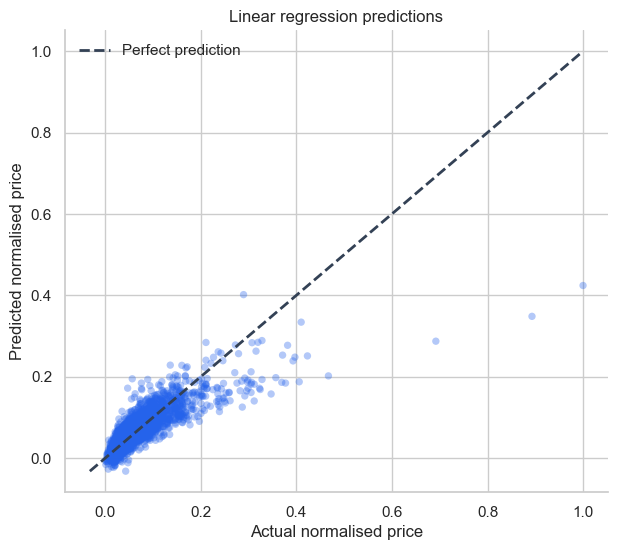

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, linear_predictions, s=28, alpha=0.35, color="#2563EB", edgecolor="none")
limits = [min(y_test.min(), linear_predictions.min()), max(y_test.max(), linear_predictions.max())]
ax.plot(limits, limits, linestyle="--", color="#334155", linewidth=2, label="Perfect prediction")
ax.set(title="Linear regression predictions", xlabel="Actual normalised price", ylabel="Predicted normalised price")
ax.legend(frameon=False)
sns.despine()
plt.show()

## 4. Random forest regression

A random forest can learn curved relationships and feature interactions.


In [6]:
forest_model = RandomForestRegressor(
    n_estimators=120, max_depth=16, min_samples_leaf=2, random_state=42, n_jobs=-1
)
forest_model.fit(X_train, y_train)
forest_predictions = forest_model.predict(X_test)

forest_results = pd.Series({
    "R²": r2_score(y_test, forest_predictions),
    "MAE": mean_absolute_error(y_test, forest_predictions),
    "RMSE": mean_squared_error(y_test, forest_predictions) ** 0.5
}, name="Random Forest")
pd.concat([linear_results, forest_results], axis=1).T.round(4)

,R²,MAE,RMSE
Linear Regression,0.6844,0.0169,0.0283
Random Forest,0.8766,0.0093,0.0177


### Cross-validation

Three folds check whether the forest performs consistently on different training subsets.


In [7]:
cv_scores = cross_val_score(forest_model, X_train, y_train, cv=3, scoring="r2", n_jobs=-1)
print("Fold R² scores:", np.round(cv_scores, 3))
print(f"Mean R²: {cv_scores.mean():.3f}")

Fold R² scores: [0.874 0.87  0.878]
Mean R²: 0.874


### Feature importance


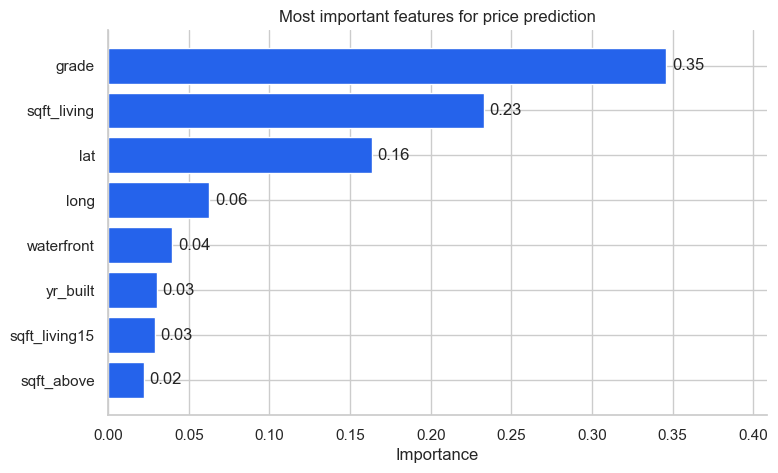

In [8]:
importance = (pd.Series(forest_model.feature_importances_, index=X.columns)
              .nlargest(8)
              .sort_values())

fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.barh(importance.index, importance.values, color="#2563EB")
ax.bar_label(bars, fmt="%.2f", padding=4)
ax.set(title="Most important features for price prediction", xlabel="Importance", ylabel="")
ax.set_xlim(0, importance.max() * 1.18)
sns.despine()
plt.show()

### Predict one test row


In [9]:
example = X_test.iloc[[5]]
actual_price = y_test.iloc[5]
predicted_price = forest_model.predict(example)[0]

print(f"Actual normalised price:    {actual_price:.3f}")
print(f"Predicted normalised price: {predicted_price:.3f}")

Actual normalised price:    0.048
Predicted normalised price: 0.051


# Part B: Classification


## 5. Create a class label

A home is labelled `High price` when its price is in the top 25% of the dataset.


In [10]:
high_price_cutoff = housing["price"].quantile(0.75)
price_class = (housing["price"] >= high_price_cutoff).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, price_class, test_size=0.20, random_state=42, stratify=price_class
)
price_class.value_counts().rename(index={0: "Regular price", 1: "High price"}).to_frame("Rows")

,Rows
price,
Regular price,16200
High price,5413


## 6. Train and evaluate the classifier


In [11]:
classifier = RandomForestClassifier(
    n_estimators=150, max_depth=14, min_samples_leaf=3, random_state=42, n_jobs=-1
)
classifier.fit(X_train_c, y_train_c)
class_predictions = classifier.predict(X_test_c)
print(f"Weighted F1 score: {f1_score(y_test_c, class_predictions, average='weighted'):.1%}")

Weighted F1 score: 92.1%


### Confusion matrix


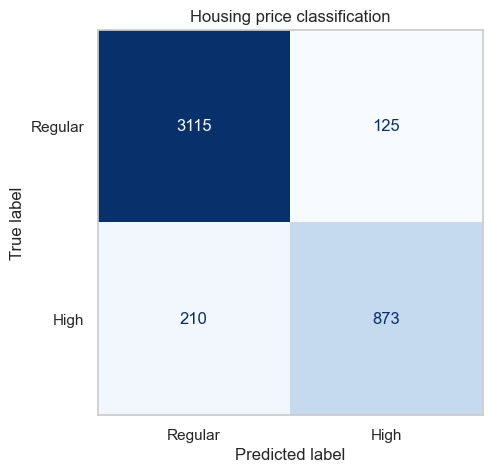

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_c, class_predictions, display_labels=["Regular", "High"],
    cmap="Blues", colorbar=False, ax=ax
)
ax.set_title("Housing price classification")
plt.grid(False)
plt.show()

## my lessons learned

- Linear regression provides an interpretable baseline.
- The random forest handles non-linear patterns and is checked with cross-validation.
- Regression predicts a value, while classification predicts a category.
- Evaluation must use data that was not used to train the model.
